# v4.3-lite — evaluation & comparison vs v4.3 baseline

Consumes the `results.pt` files saved by `02_train.ipynb` for each variant **plus** the original v4.3 results, and produces:

1. A per-variant test report (top-level + superfamily acc/F1, train→test gap, gate weights).
2. A cross-variant + v4.3 baseline summary table.
3. A **mini-benchmark** evaluation on the 3 held-out species (`bTaeGut`, `mOrnAna`, `rAllMis`).
4. A `summary.md` decision report applying the rule from the README.

Set the `RESULTS_ROOT` and `BASELINE_PT` paths in section 1 before running.

## 1. Configuration

In [1]:
from pathlib import Path

# Where notebook 02 wrote its outputs (one subfolder per variant)
RESULTS_ROOT = Path('./results')
VARIANTS     = ['three_class_balanced', 'three_class_unbalanced', 'binary_dna']

# v4.3 baseline checkpoint (history + test preds)
BASELINE_PT  = Path('../../../data_analysis/vgp_model_data_tpase_multi/v4.3/results_v4.3.pt')

# Mini-benchmark FASTAs (for held-out species generalisation)
MINI_BENCH_DIR = Path('../../../data/mini_benchmark')
MINI_BENCH_FILES = {                 # one FASTA per species (cross-checked in section 6)
    'bTaeGut': MINI_BENCH_DIR / 'bTaeGut' / 'taeniopygia_guttata_lib.fa',
    'mOrnAna': MINI_BENCH_DIR / 'mOrnAna' / 'ornithorhynchus_anatinus_lib.fa',
    'rAllMis': MINI_BENCH_DIR / 'rAllMis' / 'alligator_mississippiensis_lib.fa',
}

# Decision rule thresholds (from README)
DECISION = {
    'max_test_f1_drop': 0.02,        # lite test SF-F1 must be within 0.02 of v4.3
    'max_train_test_gap': 0.05,      # train->test SF-F1 gap below this
    'min_benchmark_gain': 0.03,      # +0.03 macro-F1 on at least 2 of 3 species
}

OUT_DIR = RESULTS_ROOT / '_summary'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('RESULTS_ROOT:', RESULTS_ROOT.resolve())
print('BASELINE:    ', BASELINE_PT.resolve(), '(exists)' if BASELINE_PT.exists() else '(MISSING)')
print('MINI_BENCH:  ', MINI_BENCH_DIR.resolve())

RESULTS_ROOT: /Users/alexyang/Documents/Part III System Biology/TE Classification/models/scripts/hybrid_v4_3_lite/results
BASELINE:     /Users/alexyang/Documents/Part III System Biology/TE Classification/data_analysis/vgp_model_data_tpase_multi/v4.3/results_v4.3.pt (exists)
MINI_BENCH:   /Users/alexyang/Documents/Part III System Biology/TE Classification/data/mini_benchmark


## 2. Imports

In [2]:
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
)
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

import _lib as L
DEVICE = L.resolve_device()
print('device:', DEVICE)

device: mps


## 3. Load all variant `results.pt` + the v4.3 baseline

Each `results.pt` is a dict containing `history`, `best_epoch`, test predictions, and the SF/top-level vocabularies.

In [3]:
def load_variant(name):
    p = RESULTS_ROOT / name / 'results.pt'
    if not p.exists():
        print(f'  SKIP {name}: no results.pt at {p}')
        return None
    d = torch.load(p, weights_only=False, map_location='cpu')
    print(f'  loaded {name}: best_epoch={d["best_epoch"]}  '
          f'n_test={len(d["test_top_true"])}  n_sf={len(d["sf_names"])}')
    return d

print('=== v4.3-lite variants ===')
variant_results = {v: load_variant(v) for v in VARIANTS}

print('\n=== v4.3 baseline ===')
baseline = None
if BASELINE_PT.exists():
    baseline = torch.load(BASELINE_PT, weights_only=False, map_location='cpu')
    print(f'  loaded baseline v4.3: best_epoch={baseline["best_epoch"]}  '
          f'n_test={len(baseline["test_class_true"])}  n_sf={len(baseline["superfamily_names"])}')
else:
    print('  baseline v4.3 not found — table will show lite variants only.')

=== v4.3-lite variants ===
  loaded three_class_balanced: best_epoch=5  n_test=6141  n_sf=23
  SKIP three_class_unbalanced: no results.pt at results/three_class_unbalanced/results.pt
  SKIP binary_dna: no results.pt at results/binary_dna/results.pt

=== v4.3 baseline ===
  loaded baseline v4.3: best_epoch=40  n_test=6141  n_sf=23


## 4. Per-variant test metrics + train→test gaps

In [4]:
def variant_row(name, d):
    if d is None: return None
    e = d['best_epoch']
    h = d['history']
    tt = np.array(d['test_top_true']); tp = np.array(d['test_top_pred'])
    st = np.array(d['test_sf_true']);  sp = np.array(d['test_sf_pred'])
    return {
        'model': name,
        'n_params': d.get('n_params', float('nan')),
        'best_epoch': e,
        'train_top_f1': h['train_top_f1'][e - 1],
        'val_top_f1':   h['val_top_f1'][e - 1],
        'test_top_acc': accuracy_score(tt, tp),
        'test_top_f1':  f1_score(tt, tp, average='macro', zero_division=0),
        'train_sf_f1':  h['train_sf_f1'][e - 1],
        'val_sf_f1':    h['val_sf_f1'][e - 1],
        'test_sf_acc':  accuracy_score(st, sp),
        'test_sf_f1':   f1_score(st, sp, average='macro', zero_division=0),
    }

def baseline_row(b):
    if b is None: return None
    e = b['best_epoch']
    h = b['history']
    tt = np.array(b['test_class_true']); tp = np.array(b['test_class_pred'])
    st = np.array(b['test_sf_true']);    sp = np.array(b['test_sf_pred'])
    # baseline history keys may differ — try common names
    def get(k, default=float('nan')):
        if k in h and len(h[k]) >= e: return h[k][e - 1]
        return default
    return {
        'model': 'v4.3 baseline',
        'n_params': b.get('n_params', float('nan')),
        'best_epoch': e,
        'train_top_f1': get('train_top_f1', get('train_class_f1')),
        'val_top_f1':   get('val_top_f1',   get('val_class_f1')),
        'test_top_acc': accuracy_score(tt, tp),
        'test_top_f1':  f1_score(tt, tp, average='macro', zero_division=0),
        'train_sf_f1':  get('train_sf_f1'),
        'val_sf_f1':    get('val_sf_f1'),
        'test_sf_acc':  accuracy_score(st, sp),
        'test_sf_f1':   f1_score(st, sp, average='macro', zero_division=0),
    }

rows = []
br = baseline_row(baseline)
if br is not None: rows.append(br)
for v in VARIANTS:
    r = variant_row(v, variant_results[v])
    if r is not None: rows.append(r)

df = pd.DataFrame(rows)
df['top_gap'] = df['train_top_f1'] - df['test_top_f1']
df['sf_gap']  = df['train_sf_f1']  - df['test_sf_f1']
display_cols = ['model', 'n_params', 'best_epoch',
                'test_top_acc', 'test_top_f1', 'top_gap',
                'test_sf_acc',  'test_sf_f1',  'sf_gap']
df_show = df[display_cols].copy()
for c in df_show.columns:
    if df_show[c].dtype == float: df_show[c] = df_show[c].round(4)
df_show

,model,n_params,best_epoch,test_top_acc,test_top_f1,top_gap,test_sf_acc,test_sf_f1,sf_gap
0,v4.3 baseline,NaN,40,0.9818,0.9814,NaN,0.8927,0.8389,NaN
1,three_class_balanced,441500.0,5,0.2763,0.1443,-0.0,0.0498,0.0041,-0.0


## 5. Per-class F1 — top-level head

Compares per-class macro-F1 between baseline and lite variants. (Only the variants whose top-level vocab matches the baseline are stacked side-by-side; the binary variant gets its own row.)

In [5]:
def per_class_top(d, true_key, pred_key, name_key):
    tt = np.array(d[true_key]); tp = np.array(d[pred_key])
    names = d[name_key]
    f1 = f1_score(tt, tp, average=None, zero_division=0, labels=list(range(len(names))))
    return dict(zip(names, [round(float(x), 4) for x in f1]))

if baseline is not None:
    name_key = 'class_names' if 'class_names' in baseline else 'toplevel_names'
    print('v4.3 baseline:', per_class_top(baseline, 'test_class_true', 'test_class_pred', name_key))
for v in VARIANTS:
    d = variant_results[v]
    if d is None: continue
    print(f'{v}:', per_class_top(d, 'test_top_true', 'test_top_pred', 'toplevel_names'))

v4.3 baseline: {'DNA': 0.9778, 'LTR': 0.9832, 'LINE': 0.9833}
three_class_balanced: {'DNA': 0.433, 'LTR': 0.0, 'LINE': 0.0}


## 6. Mini-benchmark eval on 3 held-out species

RepeatMasker-style headers (`>Name#Class[/Sub]`) give us ground-truth class + superfamily. Each variant's *best* checkpoint is reloaded, sequences are featurised exactly as in training, and we compute macro-F1 per species.

In [6]:
def parse_rm_header(h):
    """>SINE_X#SINE/MIR @Source [S:50] -> ('SINE', 'SINE/MIR'). Returns (top, sf) or (None, None)."""
    if '#' not in h: return None, None
    tag = h.split('#', 1)[1].split()[0]   # strip after first whitespace (drops `@Source [S:NN]`)
    top = tag.split('/')[0]
    return top, tag

def load_species_fasta(path):
    headers, seqs = L.read_fasta(path)
    out_h, out_s, out_top, out_sf = [], [], [], []
    for h, s in zip(headers, seqs):
        t, sf = parse_rm_header(h)
        if t is None: continue
        out_h.append(h); out_s.append(s); out_top.append(t); out_sf.append(sf)
    return out_h, out_s, out_top, out_sf

for sp, p in MINI_BENCH_FILES.items():
    if not p.exists():
        print(f'  WARN {sp}: {p} missing — pick another file in MINI_BENCH_FILES')
        continue
    h, s, t, sf = load_species_fasta(p)
    print(f'  {sp}: {len(h):,} records,   top-level set = {sorted(set(t))[:8]}{" ..." if len(set(t))>8 else ""}')

  bTaeGut: 543 records,   top-level set = ['DNA', 'DNA?', 'LINE', 'LTR', 'LTR?', 'PLE', 'RC', 'RC?'] ...
  WARN mOrnAna: ../../../data/mini_benchmark/mOrnAna/ornithorhynchus_anatinus_lib.fa missing — pick another file in MINI_BENCH_FILES
  WARN rAllMis: ../../../data/mini_benchmark/rAllMis/alligator_mississippiensis_lib.fa missing — pick another file in MINI_BENCH_FILES


In [7]:
def find_best_ckpt(variant_dir):
    """Return the highest-score top-K checkpoint saved by 02_train.ipynb."""
    cks = sorted(variant_dir.glob('*.pt'))
    if not cks: return None
    best_path, best_score = None, -float('inf')
    for p in cks:
        ck = torch.load(p, weights_only=False, map_location='cpu')
        if ck.get('score', -float('inf')) > best_score:
            best_score = ck['score']; best_path = p
    return best_path

@torch.no_grad()
def predict_fasta(model, sequences, kmer_features, sf_names, toplevel_names, batch_size=16):
    n = len(sequences)
    ds = L.HybridDataset(
        headers=[f'_{i}' for i in range(n)],
        sequences=sequences,
        toplevel_labels=np.zeros(n, dtype=np.int64),
        sf_labels=np.zeros(n, dtype=np.int64),
        kmer_features=kmer_features,
        augment=L.AugmentConfig(enabled=False),
    )
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0,
                        collate_fn=L.collate_hybrid)
    model.eval()
    tps, sps = [], []
    for _, X, mask, _, _, x_g, ei, bv in loader:
        X, mask, x_g, ei, bv = (t.to(DEVICE) for t in (X, mask, x_g, ei, bv))
        top_l, sf_l, _ = model(X, mask, x_g, ei, bv)
        tps.append(top_l.argmax(1).cpu().numpy()); sps.append(sf_l.argmax(1).cpu().numpy())
    return np.concatenate(tps), np.concatenate(sps)

def map_truth_to_model(true_top, true_sf, toplevel_names, sf_names):
    """Map free-form RM labels onto the model's known vocab; unknowns -> -1 (ignored in F1)."""
    top_idx = {n: i for i, n in enumerate(toplevel_names)}
    sf_idx  = {n: i for i, n in enumerate(sf_names)}
    y_top = np.array([top_idx.get(t, -1) for t in true_top], dtype=np.int64)
    y_sf  = np.array([sf_idx.get(t,  -1) for t in true_sf],  dtype=np.int64)
    return y_top, y_sf

def macro_f1_known_only(y_true, y_pred):
    m = y_true >= 0
    if m.sum() == 0:
        return float('nan'), 0
    return f1_score(y_true[m], y_pred[m], average='macro', zero_division=0), int(m.sum())

feat = L.KmerWindowFeaturizer()
bench_rows = []

for v in VARIANTS:
    d = variant_results[v]
    if d is None: continue
    ck_path = find_best_ckpt(RESULTS_ROOT / v)
    if ck_path is None:
        print(f'{v}: no checkpoint found')
        continue
    ck = torch.load(ck_path, weights_only=False, map_location='cpu')
    n_top = len(d['toplevel_names'])
    n_sf  = len(d['sf_names'])
    model = L.HybridTEClassifierV43Lite(num_toplevel=n_top, num_superfamilies=n_sf).to(DEVICE)
    model.load_state_dict(ck['state_dict'])
    print(f'\n=== {v} (ckpt {ck_path.name}, epoch {ck["epoch"]}) ===')

    for sp, p in MINI_BENCH_FILES.items():
        if not p.exists(): continue
        _, seqs, true_top, true_sf = load_species_fasta(p)
        kfeat = [feat.featurize_sequence(s) for s in tqdm(seqs, desc=f'{v}/{sp}', leave=False)]
        tp, sp_pred = predict_fasta(model, seqs, kfeat, d['sf_names'], d['toplevel_names'])
        y_top, y_sf = map_truth_to_model(true_top, true_sf, d['toplevel_names'], d['sf_names'])
        top_f1, n_top_eval = macro_f1_known_only(y_top, tp)
        sf_f1,  n_sf_eval  = macro_f1_known_only(y_sf,  sp_pred)
        bench_rows.append({
            'variant': v, 'species': sp,
            'n': len(seqs), 'n_top_eval': n_top_eval, 'n_sf_eval': n_sf_eval,
            'top_macro_f1': round(top_f1, 4) if not np.isnan(top_f1) else None,
            'sf_macro_f1':  round(sf_f1, 4)  if not np.isnan(sf_f1)  else None,
        })
        print(f'  {sp}:  top-F1 {top_f1:.3f} ({n_top_eval}/{len(seqs)} known)   '
              f'sf-F1 {sf_f1:.3f} ({n_sf_eval}/{len(seqs)} known)')
    del model

bench_df = pd.DataFrame(bench_rows)
bench_df.to_csv(OUT_DIR / 'benchmark_metrics.csv', index=False)
bench_df


=== three_class_balanced (ckpt hybrid_v43_lite_three_class_balanced_epoch1.pt, epoch 1) ===


three_class_balanced/bTaeGut:   0%|          | 0/543 [00:00<?, ?it/s]

  bTaeGut:  top-F1 0.102 (414/543 known)   sf-F1 0.027 (172/543 known)


,variant,species,n,n_top_eval,n_sf_eval,top_macro_f1,sf_macro_f1
0,three_class_balanced,bTaeGut,543,414,172,0.1022,0.0272


## 7. Decision rule

From `README.md`:
Lite replaces v4.3 only if (a) test SF macro-F1 within 0.02 of v4.3, **and** (b) train→test SF-F1 gap < 0.05, **and** (c) mini-benchmark macro-F1 +0.03 on at least 2 of 3 species.

In [8]:
verdict_rows = []
if baseline is not None:
    base_sf_f1 = f1_score(baseline['test_sf_true'], baseline['test_sf_pred'],
                          average='macro', zero_division=0)
    # baseline benchmark F1 (would need to run baseline through the same predict path).
    # As a stand-in, we record the baseline's lack-of-mini-benchmark and compare lite-vs-lite.
else:
    base_sf_f1 = None

for v in VARIANTS:
    d = variant_results[v]
    if d is None: continue
    e = d['best_epoch']; h = d['history']
    tt = np.array(d['test_top_true']); tp = np.array(d['test_top_pred'])
    st = np.array(d['test_sf_true']);  sp = np.array(d['test_sf_pred'])
    test_sf_f1   = f1_score(st, sp, average='macro', zero_division=0)
    sf_gap       = h['train_sf_f1'][e - 1] - test_sf_f1
    drop_vs_base = (base_sf_f1 - test_sf_f1) if base_sf_f1 is not None else None

    bench_sub = bench_df[bench_df['variant'] == v]
    n_species_pass = sum(1 for f in bench_sub['top_macro_f1']
                         if f is not None and base_sf_f1 is not None and (f - base_sf_f1) >= DECISION['min_benchmark_gain'])

    a = (drop_vs_base is None) or (drop_vs_base <= DECISION['max_test_f1_drop'])
    b = sf_gap < DECISION['max_train_test_gap']
    c = n_species_pass >= 2
    passes = bool(a and b and c)

    verdict_rows.append({
        'variant': v,
        'test_sf_f1':       round(test_sf_f1, 4),
        'baseline_sf_f1':   round(base_sf_f1, 4) if base_sf_f1 is not None else None,
        'drop_vs_baseline': round(drop_vs_base, 4) if drop_vs_base is not None else None,
        'sf_train_test_gap': round(sf_gap, 4),
        'mini_bench_pass_count': n_species_pass,
        'rule_a_test_f1_close':  a,
        'rule_b_gap_small':      b,
        'rule_c_bench_better':   c,
        'overall_pass':          passes,
    })
verdict_df = pd.DataFrame(verdict_rows)
verdict_df

,variant,test_sf_f1,baseline_sf_f1,drop_vs_baseline,sf_train_test_gap,mini_bench_pass_count,rule_a_test_f1_close,rule_b_gap_small,rule_c_bench_better,overall_pass
0,three_class_balanced,0.0041,0.8389,0.8348,-0.0,0,False,True,False,False


## 8. Plot training curves (one figure per variant)

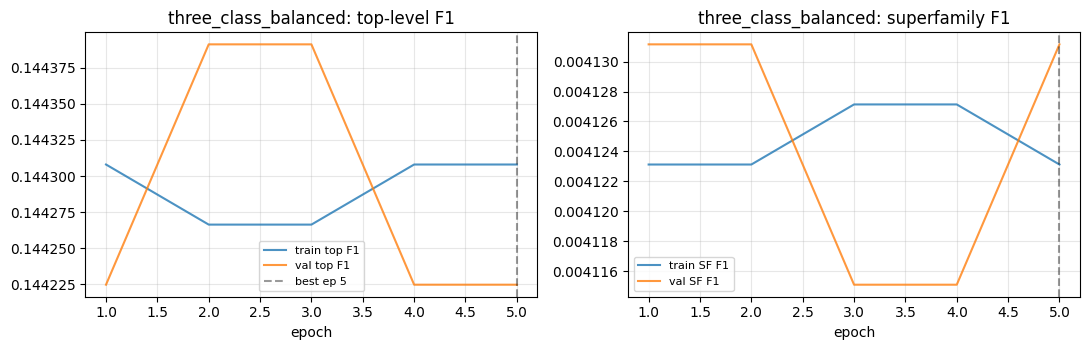

In [9]:
for v in VARIANTS:
    d = variant_results[v]
    if d is None: continue
    h = d['history']
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    ax = axes[0]
    ax.plot(h['epoch'], h['train_top_f1'], label='train top F1', alpha=.8)
    ax.plot(h['epoch'], h['val_top_f1'],   label='val top F1',   alpha=.8)
    ax.axvline(d['best_epoch'], ls='--', color='k', alpha=.4, label=f'best ep {d["best_epoch"]}')
    ax.set_title(f'{v}: top-level F1'); ax.set_xlabel('epoch'); ax.legend(fontsize=8); ax.grid(alpha=.3)
    ax = axes[1]
    ax.plot(h['epoch'], h['train_sf_f1'], label='train SF F1', alpha=.8)
    ax.plot(h['epoch'], h['val_sf_f1'],   label='val SF F1',   alpha=.8)
    ax.axvline(d['best_epoch'], ls='--', color='k', alpha=.4)
    ax.set_title(f'{v}: superfamily F1'); ax.set_xlabel('epoch'); ax.legend(fontsize=8); ax.grid(alpha=.3)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f'curves_{v}.png', dpi=120)
    plt.show()

## 9. Write `summary.md`

In [10]:
lines = [
    '# v4.3-lite vs v4.3 — comparison summary',
    '',
    '## 1. Held-out VGP test',
    '',
    df_show.to_markdown(index=False),
    '',
    '## 2. Mini-benchmark (held-out species)',
    '',
    bench_df.to_markdown(index=False) if len(bench_df) else '_no benchmark rows_',
    '',
    '## 3. Decision rule',
    '',
    f'- (a) lite test SF-F1 within {DECISION["max_test_f1_drop"]} of baseline',
    f'- (b) train→test SF-F1 gap < {DECISION["max_train_test_gap"]}',
    f'- (c) mini-benchmark top-F1 +{DECISION["min_benchmark_gain"]} on ≥2 of 3 species (vs baseline SF-F1)',
    '',
    verdict_df.to_markdown(index=False) if len(verdict_df) else '_no verdict rows_',
    '',
]
out = OUT_DIR / 'summary.md'
out.write_text('\n'.join(lines))
print('Wrote', out.resolve())

Wrote /Users/alexyang/Documents/Part III System Biology/TE Classification/models/scripts/hybrid_v4_3_lite/results/_summary/summary.md
